# Profitability & Sales Optimization

## Problem Statement:

## Despite a high volume of overall orders, the company lacks visibility into which specific product lines and customer regions are driving true profitability versus just revenue. This dashboard aims to identify our most and least profitable segments to optimize future marketing and pricing strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy as sa
import pyodbc 
import datetime as dt

In [2]:
connection_string = (
    "mssql+pyodbc://@"
    "OMKAR\\SQLEXPRESS/"
    "DataWarehouse"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&Trusted_Connection=yes"
)

In [3]:
from sqlalchemy import create_engine, text

server = 'localhost\\SQLEXPRESS'
database = 'DataWarehouse'      

connection_url = f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&Trusted_Connection=yes"

engine = create_engine(connection_url)

with engine.connect() as connection:
    print("Connected successfully!")

Connected successfully!


In [4]:
query  = '''
		SELECT 
			c.customer_key,
			c.first_name,
			c.last_name,
			c.country,
			c.marital_status,
			c.gender,
			c.birthdate,
			p.product_key,
			p.product_name,
			p.category,
			p.subcategory,
			p.maintenance,
			p.product_cost,
			p.product_line,
			p.start_date,
			s.order_number,
			s.order_date,
			s.shipping_date,
			s.due_date,
			s.price,
			s.quantity,
			s.sales_amount
		FROM gold.fact_sales AS s
		LEFT JOIN gold.dim_customers AS c
		ON s.customer_key = c.customer_key
		LEFT JOIN gold.dim_products AS p
		ON s.product_key = p.product_key;
''' 
df = pd.read_sql(query,con=engine)

In [5]:
df.dtypes

customer_key       int64
first_name           str
last_name            str
country              str
marital_status       str
gender               str
birthdate         object
product_key        int64
product_name         str
category             str
subcategory          str
maintenance          str
product_cost       int64
product_line         str
start_date        object
order_number         str
order_date        object
shipping_date     object
due_date          object
price              int64
quantity           int64
sales_amount       int64
dtype: object

In [6]:
df['birthdate'] = pd.to_datetime(df['birthdate'])
df['start_date'] = pd.to_datetime(df['start_date'])
df['order_date'] = pd.to_datetime(df['order_date'])
df['shipping_date'] = pd.to_datetime(df['shipping_date'])
df['due_date'] = pd.to_datetime(df['due_date'])

In [7]:
df['gender'][df['gender'] == 'n/a'].count()

np.int64(33)

In [8]:
df['country'][df['country'] == 'n/a'].count()

np.int64(871)

### Feature Engineering

In [9]:
df['total_cost'] = df['product_cost'] * df['quantity']
df['total_profit'] = df['sales_amount'] - df['total_cost']
df['profit_margin%'] = (df['total_profit'] / df['sales_amount']) * 100
df['month_num'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()
now = pd.Timestamp.now()

df['age'] = (
    now.year - df['birthdate'].dt.year - 
    ((now.month < df['birthdate'].dt.month) | 
    ((now.month == df['birthdate'].dt.month) & (now.day < df['birthdate'].dt.day))).astype(int)
)

df['shipping_lag_days'] =( df['shipping_date'] - df['order_date']).dt.days

### Who are our most profitable customers? What percentage of our total profit comes from our top 10% of customers (High M)?

In [10]:
# Who are our most profitable customers?
print('Top 5 most profitable customers.')

profitable_customers = df.groupby(['customer_key','first_name','last_name']).agg(
    total_revenue = ('sales_amount', 'sum'),
    total_profit = ('total_profit', 'sum')
    ).reset_index()

profitable_customers['profit_margin%'] = (profitable_customers['total_profit'] / profitable_customers['total_revenue']) * 100
top_customers = profitable_customers.sort_values(by='total_profit', ascending=False)
print(top_customers.head(5))

overall_profit = profitable_customers['total_profit'].sum()

top_10_per_count = int(len(top_customers)* 0.10)
top_profit_sum = top_customers.head(top_10_per_count)['total_profit'].sum()

profit_contribution = (top_profit_sum / overall_profit) * 100

print(f'\n Profit contribution of top 10% customers {profit_contribution:.2f}')


Top 5 most profitable customers.
      customer_key first_name  last_name  total_revenue  total_profit  \
1132          1133    Kaitlyn  Henderson          13294          5274   
1308          1309   Margaret         He          13268          5254   
1301          1302    Nichole       Nara          13294          5250   
1300          1301    Adriana   Gonzalez          13242          5236   
1131          1132    Randall  Dominguez          13265          5231   

      profit_margin%  
1132       39.672032  
1308       39.599035  
1301       39.491500  
1300       39.540855  
1131       39.434602  

 Profit contribution of top 10% customers 41.21


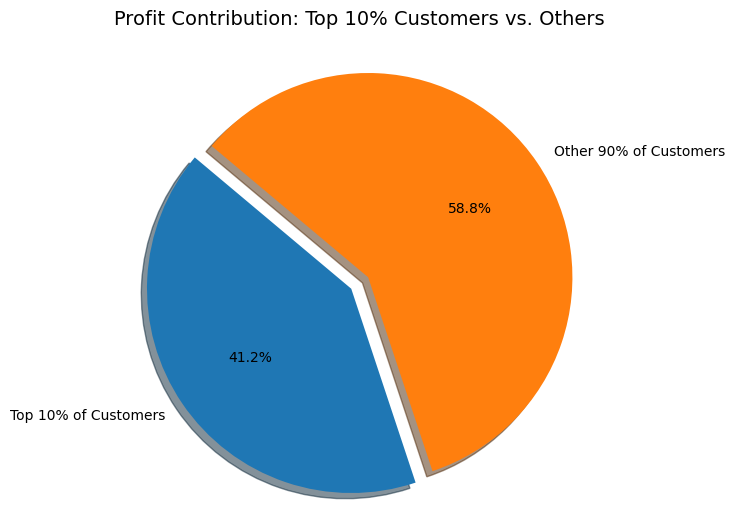

In [11]:
top_10_profit = top_customers.iloc[:top_10_per_count]['total_profit'].sum()
others_profit = top_customers.iloc[top_10_per_count:]['total_profit'].sum()
labels = ['Top 10% of Customers', 'Other 90% of Customers']
sizes = [top_10_profit, others_profit]
explode = (0.1, 0)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels,autopct='%1.1f%%',shadow=True, startangle=140)

plt.title('Profit Contribution: Top 10% Customers vs. Others', fontsize=14, pad=20)
plt.axis('equal') 

# Render the chart
plt.show()

### Are high-revenue customers actually profitable? Are there customers who spend a lot of total money, but mostly buy low-margin products, resulting in a low true profitability score?

In [12]:
## Are high-revenue customers actually profitable?

customer_metric = df.groupby(['customer_key','first_name','last_name']).agg(
        total_revenue = ('sales_amount','sum'),
        total_profit = ('total_profit','sum')
    ).reset_index()

customer_metric['effective_margin'] = (customer_metric['total_profit'] / customer_metric['total_revenue'] * 100 )

customer_metric['revenue_rank'] = customer_metric['total_revenue'].rank(ascending=False,method='min')

customer_metric['profit_rank'] = customer_metric['total_profit'].rank(ascending=False,method='min')

customer_metric['rank_penalty'] = customer_metric['profit_rank'] - customer_metric['revenue_rank']

top_revenue_customers = customer_metric[customer_metric['revenue_rank'] <= 100]

worst_offenders = customer_metric[(customer_metric['revenue_rank'] <= 100) & (customer_metric['rank_penalty'] > 0)].sort_values(by='rank_penalty', ascending=False)

worst_offenders_in_top_revenue_customers = top_revenue_customers[top_revenue_customers['rank_penalty'] > 0]

percetage_of_high_revenue_low_profit_cust = (worst_offenders['customer_key'].count() / customer_metric['customer_key'].count()) * 100

percetage_of_high_revenue_low_profit_in_top_revenue_customers = (worst_offenders_in_top_revenue_customers['customer_key'].count() / top_revenue_customers['customer_key'].count()) *100

print(f"High Revenue, Low Profit Customers do exists but the are {percetage_of_high_revenue_low_profit_cust:.2f}% of Total customers")

print(f"High Revenue, Low Profit Customers do exists but the are {percetage_of_high_revenue_low_profit_in_top_revenue_customers:.2f}% of Top {top_revenue_customers['customer_key'].count()} revenue customers")


High Revenue, Low Profit Customers do exists but the are 0.31% of Total customers
High Revenue, Low Profit Customers do exists but the are 57.00% of Top 100 revenue customers


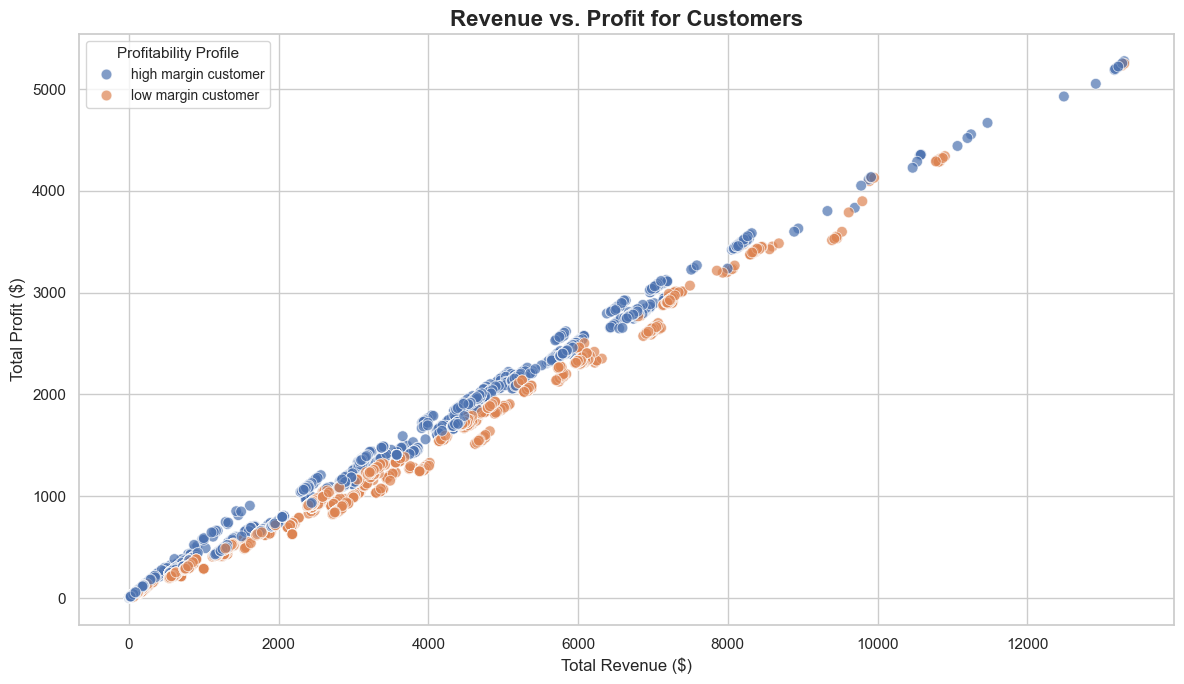

In [13]:
cus_df= customer_metric.copy()

cus_df['customer_type'] = cus_df['rank_penalty'].apply(
    lambda x: 'low margin customer' if x > 0 else 'high margin customer'
)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,7))

sns.scatterplot(data=cus_df, x='total_revenue', y= 'total_profit',hue='customer_type',s=60, alpha = 0.7)

plt.title('Revenue vs. Profit for Customers', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)

plt.legend(title='Profitability Profile', title_fontsize='11', fontsize='10', loc='upper left')

plt.tight_layout()
plt.show()

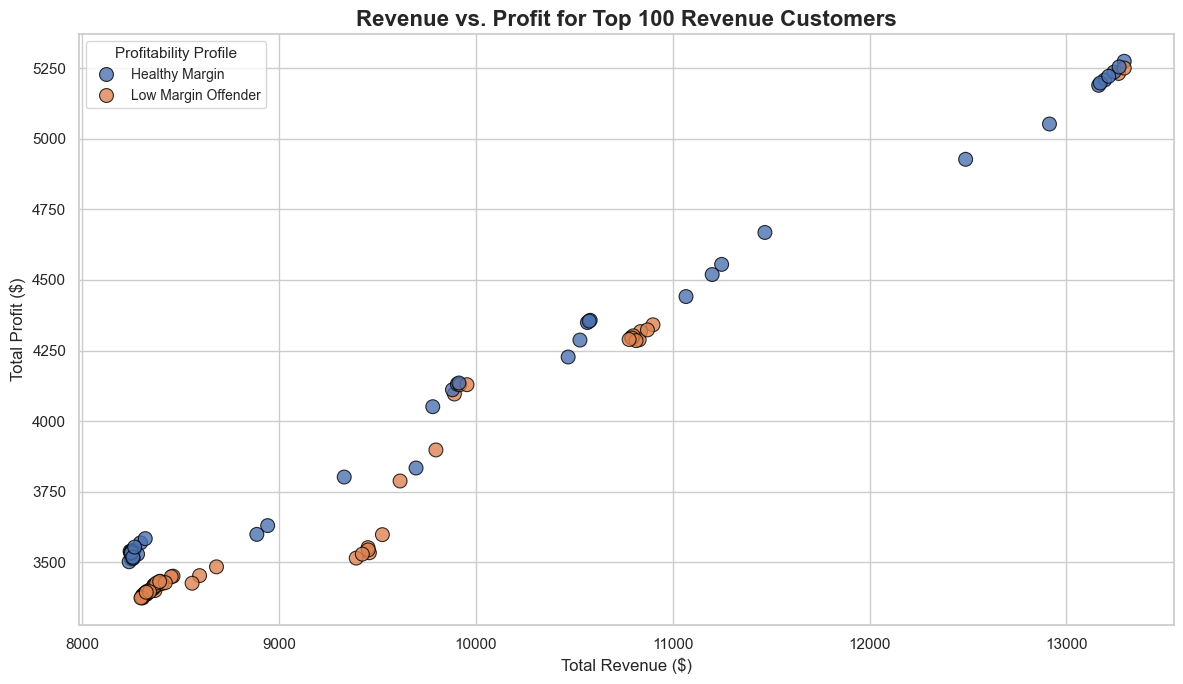

In [14]:
top_100_df = top_revenue_customers.copy()

top_100_df['Customer Type'] = top_100_df['rank_penalty'].apply(
    lambda x: 'Low Margin Offender' if x > 0 else 'Healthy Margin'
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

sns.scatterplot(data=top_100_df, x='total_revenue', y='total_profit', hue='Customer Type', s=100, alpha=0.8, edgecolor='black')

plt.title('Revenue vs. Profit for Top 100 Revenue Customers', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)

plt.legend(title='Profitability Profile', title_fontsize='11', fontsize='10', loc='upper left')

plt.tight_layout()
plt.show()

### Which product lines are "Revenue Illusions"? Which product categories or subcategories generate the top 20% of total revenue but fall into the bottom 50% for profit margin?

In [15]:
product_line_metric =df.groupby(['product_line','category', 'subcategory', 'product_name']).agg(
    total_revenue = ('sales_amount','sum'),
    total_profit = ('total_profit','sum'),
    total_quantity = ('quantity', 'sum'),
    total_product_cost = ('product_cost','sum')
).reset_index()

product_line_metric['effective_margin'] = (product_line_metric['total_profit'] / product_line_metric['total_revenue'] * 100 )

product_line_metric['Revenue_pct_rank'] = product_line_metric['total_revenue'].rank(ascending=False, method='min', pct=True)

product_line_metric['margin_pct_rank'] = product_line_metric['effective_margin'].rank(ascending=False,method='min', pct=True)

revenue_illusion = product_line_metric[
    (product_line_metric['Revenue_pct_rank'] <= 0.20) &
    (product_line_metric['margin_pct_rank'] <= 0.50)
]

columns_to_show = [
    'product_line', 
    'category', 
    'subcategory', 
    'product_name', 
    'total_revenue', 
    'effective_margin'
]
 
revenue_illusion_result = revenue_illusion[columns_to_show].sort_values(by='total_revenue', ascending=False)

revenue_illusion_result


,product_line,category,subcategory,product_name,total_revenue,effective_margin
17,Mountain,Bikes,Mountain Bikes,Mountain-200 Black- 46,1373454,43.482636
16,Mountain,Bikes,Mountain Bikes,Mountain-200 Black- 42,1363128,43.605589
18,Mountain,Bikes,Mountain Bikes,Mountain-200 Silver- 38,1339394,43.665867
20,Mountain,Bikes,Mountain Bikes,Mountain-200 Silver- 46,1301029,43.561596
15,Mountain,Bikes,Mountain Bikes,Mountain-200 Black- 38,1294854,43.726165
19,Mountain,Bikes,Mountain Bikes,Mountain-200 Silver- 42,1257368,43.615552
44,Road,Bikes,Road Bikes,Road-150 Red- 48,1205786,39.323644
47,Road,Bikes,Road Bikes,Road-150 Red- 62,1202208,39.323644
45,Road,Bikes,Road Bikes,Road-150 Red- 52,1080556,39.323644
46,Road,Bikes,Road Bikes,Road-150 Red- 56,1055510,39.323644


### Who are the hidden gems (High Margin in 20%, Low Volume in 10%)? Are there specific product_names or subcategory items that have exceptional profit margins but low overall quantity sold?

In [16]:
product_line_metric['volume_pct_rank'] = product_line_metric['total_quantity'].rank(ascending=False,method='min',pct=True)

hidden_gems = product_line_metric[
    (product_line_metric['margin_pct_rank'] <= 0.10) & 
    (product_line_metric['volume_pct_rank'] >= 0.80)
]

columns_to_show = [
    'product_line', 
    'category', 
    'subcategory', 
    'product_name', 
    'total_quantity', 
    'effective_margin'
]

hidden_gems_result = hidden_gems[columns_to_show].sort_values(by='effective_margin',ascending=False)
hidden_gems_result

,product_line,category,subcategory,product_name,total_quantity,effective_margin


### How does product cost impact the bottom line? Is there a correlation between higher product_cost items and tighter profit margins, or are we successfully passing those costs to the customer?

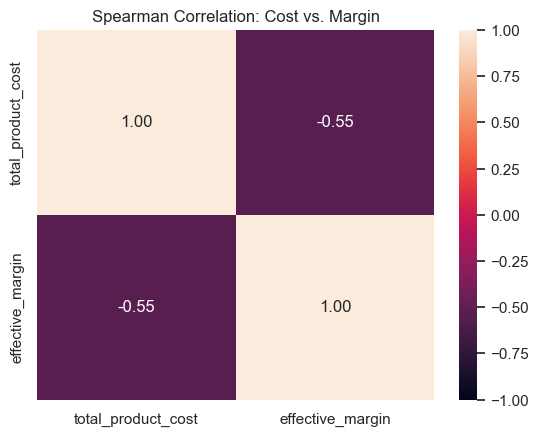

,total_product_cost,effective_margin
total_product_cost,1.000000,-0.546666
effective_margin,-0.546666,1.000000


In [17]:
correlation_metric = product_line_metric[['total_product_cost','effective_margin']].corr(method='spearman')

plt.title('Spearman Correlation: Cost vs. Margin')
sns.heatmap(correlation_metric, annot=True, fmt = '.2f', vmin=-1, vmax= 1)
plt.show()

correlation_metric

### Does the maintenance flag/cost cannibalize product profitability? How do products requiring maintenance compare in lifetime profit margin against those that do not?

In [18]:
maintenance_metric = df.groupby('maintenance').agg(
    total_profit = ('total_profit','sum'),
    total_revenue = ('sales_amount', 'sum')
)
maintenance_metric['effective_margin'] = (maintenance_metric['total_profit'] / maintenance_metric['total_revenue']) * 100
maintenance_metric

,total_profit,total_revenue,effective_margin
maintenance,,,
No,251421,523277,48.047401
Yes,11434336,28832973,39.657152


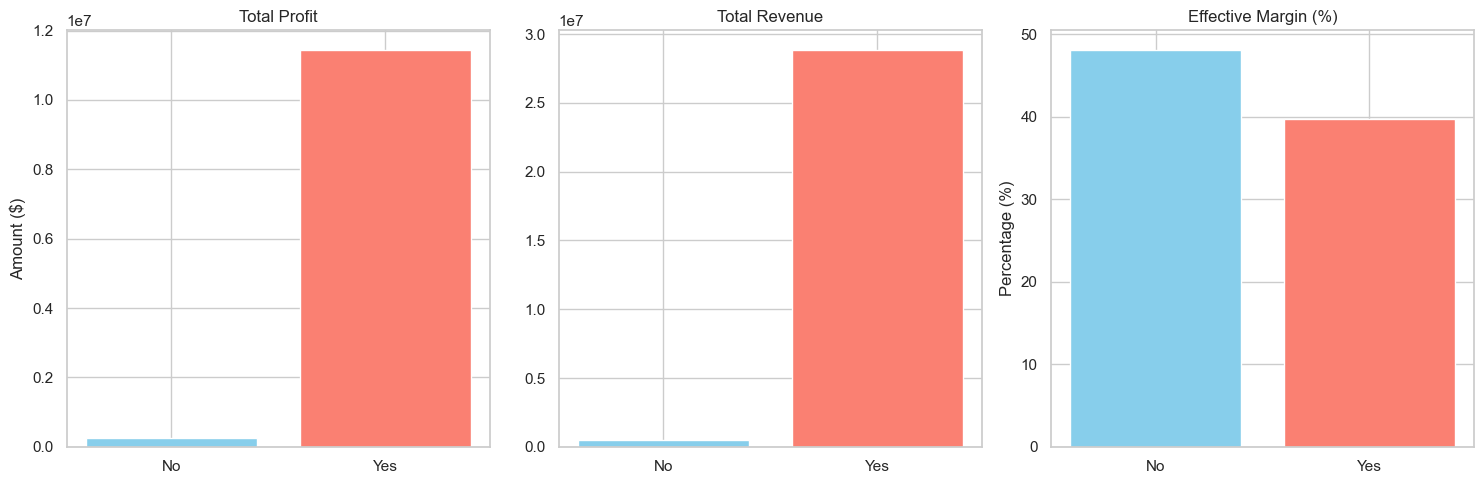

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['skyblue','salmon']

axes[0].bar(maintenance_metric.index,maintenance_metric['total_profit'], color = colors)
axes[0].set_title('Total Profit')
axes[0].set_ylabel('Amount ($)')

axes[1].bar(maintenance_metric.index,maintenance_metric['total_revenue'], color = colors)
axes[1].set_title('Total Revenue')

axes[2].bar(maintenance_metric.index,maintenance_metric['effective_margin'], color = colors)
axes[2].set_title('Effective Margin (%)')
axes[2].set_ylabel('Percentage (%)')

plt.tight_layout()

plt.show()

### Which countries are driving true profit? Rank the country column not just by total sales amount, but by average profit margin per order.

In [20]:
country_metric =df.groupby('country').agg(
    total_revenue = ('sales_amount','sum'),
    total_profit = ('total_profit','sum'),
    avg_margin_per_order = ('profit_margin%', 'mean'),
    total_orders = ('sales_amount','count')
).reset_index()

country_metric['profit_margin']= (country_metric['total_profit'] / country_metric['total_revenue']) * 100

country_ranked = country_metric.sort_values(by='avg_margin_per_order', ascending=False).reset_index(drop=True)

country_ranked['margin_rank'] = country_ranked.index + 1
country_ranked['sales_rank'] = country_ranked['total_revenue'].rank(ascending=False,method='min').astype(int)
country_ranked[['margin_rank', 'country', 'avg_margin_per_order', 'sales_rank', 'total_revenue', 'total_profit']]

,margin_rank,country,avg_margin_per_order,sales_rank,total_revenue,total_profit
0,1,Canada,55.620672,6,1977738,811661
1,2,United States,53.307691,1,9162327,3715394
2,3,France,52.234176,5,2643751,1041862
3,4,United Kingdom,51.876525,3,3391376,1342468
4,5,Germany,51.623349,4,2894066,1147605
5,6,n/a,51.313509,7,226820,84634
6,7,Australia,50.705433,2,9060172,3542133


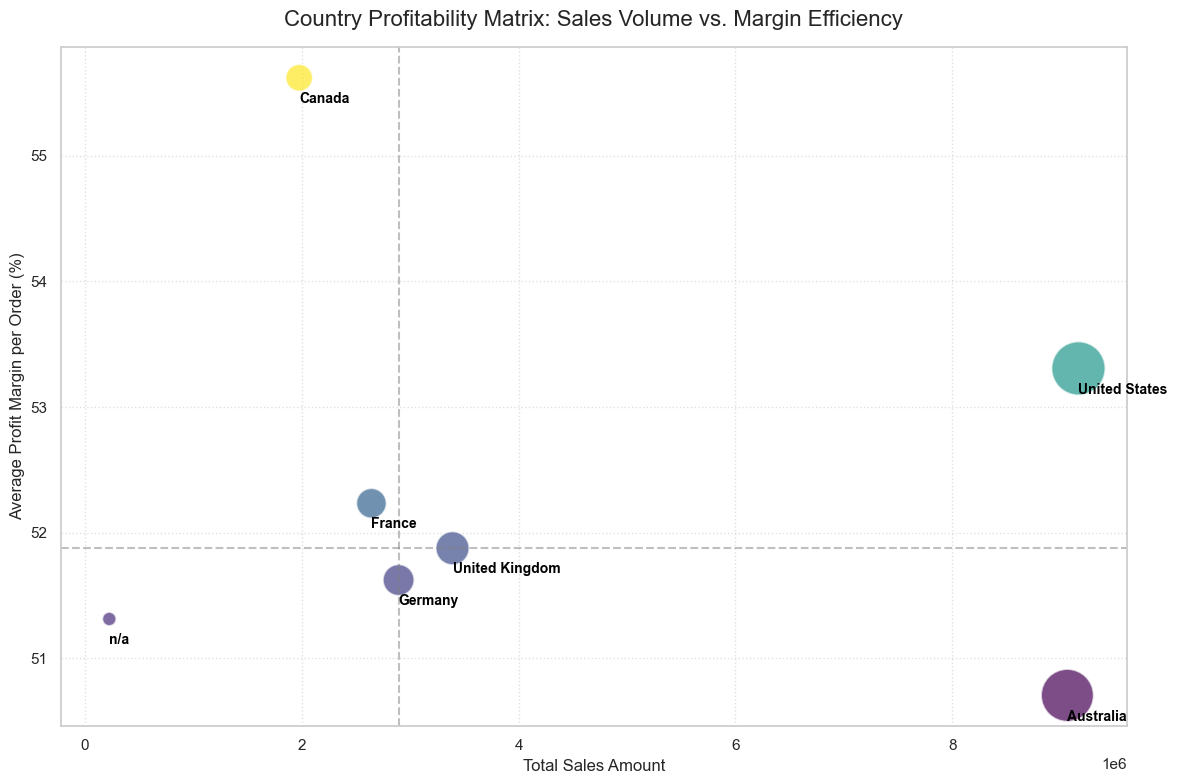

In [21]:
plt.figure(figsize=(12, 8))


sns.scatterplot(
    data=country_metric, 
    x='total_revenue', 
    y='avg_margin_per_order', 
    size='total_profit', 
    sizes=(100, 1500),
    hue='avg_margin_per_order',
    palette='viridis', 
    alpha=0.7,
    legend=False
)

for i in range(country_metric.shape[0]):
    plt.text(
        x=country_metric['total_revenue'][i], 
        y=country_metric['avg_margin_per_order'][i] - 0.2,
        s=country_metric['country'][i], 
        fontdict=dict(color='black', size=10, weight='bold')
    )

plt.title('Country Profitability Matrix: Sales Volume vs. Margin Efficiency', fontsize=16, pad=15)
plt.xlabel('Total Sales Amount', fontsize=12)
plt.ylabel('Average Profit Margin per Order (%)', fontsize=12)

plt.axvline(country_metric['total_revenue'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(country_metric['avg_margin_per_order'].median(), color='gray', linestyle='--', alpha=0.5)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

### Are there regional pricing inefficiencies? Do the same product_category items yield drastically different profit margins depending on the country they are sold in?

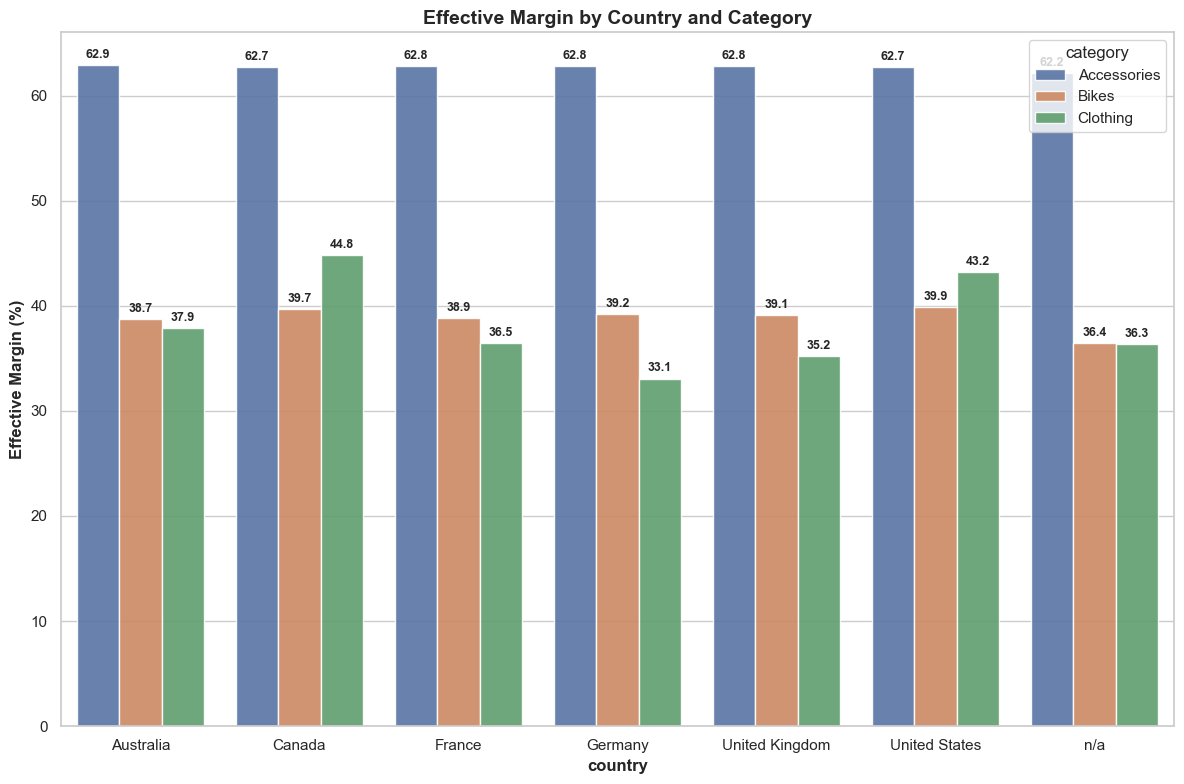

total_revenue  total_profit  effective_margin
country        category                                                  
Australia      Accessories         138567         87129         62.878607
               Bikes              8851429       3428417         38.732921
               Clothing             70176         26587         37.886172
Canada         Accessories         103393         64817         62.689931
               Bikes              1821196        723007         39.699571
               Clothing             53149         23837         44.849386
France         Accessories          63315         39752         62.784490
               Bikes              2553423        992257         38.859876
               Clothing             27013          9853         36.475031
Germany        Accessories          62133         39029         62.815251
               Bikes              2808337       1100771         39.196542
               Clothing             23596          7805         33.077640
United Kingdom Accessories          76547         48055         62.778424
               Bikes              3282624       1283065         39.086566
               Clothing             32205         11348         35.236764
United States  Accessories         248558        155911         62.726205
               Bikes              8787397       3504848         39.884940
               Clothing            126372         54635         43.233469
n/a            Accessories           7749          4817         62.162860
               Bikes               211866         77200         36.438126
               Clothing              7205          2617         36.321999

In [22]:
regional_metric = df.groupby(['country','category']).agg(
    total_revenue = ('sales_amount','sum'),
    total_profit = ('total_profit','sum')
)

regional_metric['effective_margin'] = (regional_metric['total_profit'] / regional_metric['total_revenue']) * 100

plt.figure(figsize=(12, 8))
plt.title('Effective Margin by Country and Category', fontsize=14, fontweight='bold')

ax = sns.barplot(data=regional_metric, x='country', y= 'effective_margin', legend='auto', hue = 'category' ,alpha = 0.9)

plt.xlabel('country', fontsize=12, fontweight='bold')
plt.ylabel('Effective Margin (%)', fontsize=12, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding= 3, size = 9, weight = 'bold')

plt.tight_layout()

plt.show()

regional_metric

### Where is our most profitable customer base concentrated? If we map the top 20% most profitable customers, which countries dominate the visual?

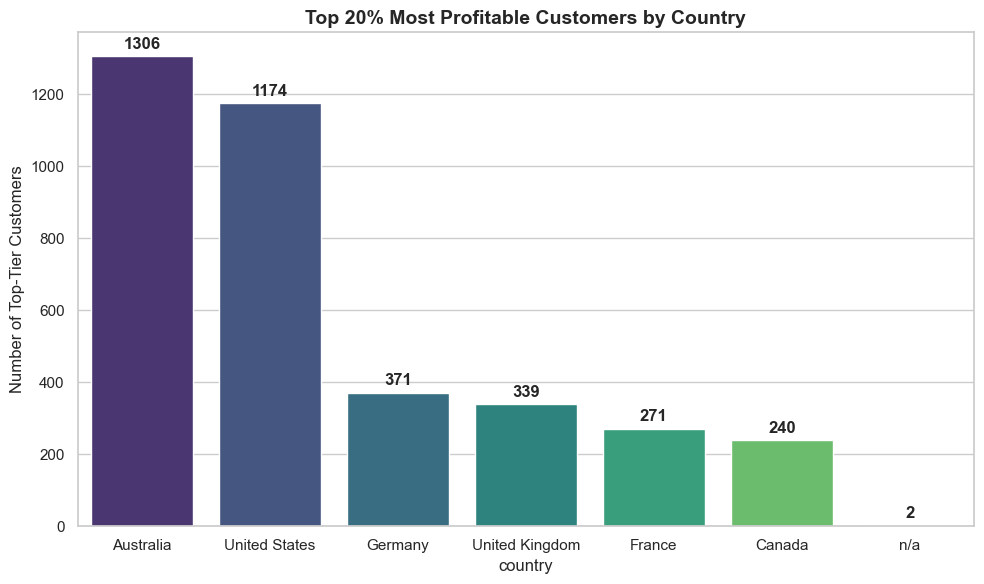

,country,customer_count,share_pct
0,Australia,1306,0.352687
1,United States,1174,0.317040
2,Germany,371,0.100189
3,United Kingdom,339,0.091547
4,France,271,0.073184
5,Canada,240,0.064812
6,n/a,2,0.000540


In [23]:
regional_profit_metric = df.groupby(['country','customer_key'])['total_profit'].sum().reset_index()

p80_threshold = regional_profit_metric['total_profit'].quantile(0.80)

top_20 = regional_profit_metric[regional_profit_metric['total_profit'] >= p80_threshold]

country_counts = top_20['country'].value_counts().reset_index()
country_counts.columns = ['country','customer_count']

total_top_20_customer = country_counts['customer_count'].sum()

country_counts['share_pct'] = country_counts['customer_count'] / total_top_20_customer

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data = country_counts,
    x = 'country',
    y = 'customer_count',
    hue = 'country',
    palette = 'viridis'
)

plt.title('Top 20% Most Profitable Customers by Country', fontsize = 14, fontweight = 'bold')

plt.xlabel('country', fontsize = 12)
plt.ylabel('Number of Top-Tier Customers', fontsize = 12)

for i in ax.containers:
    ax.bar_label(i,fmt = '%d', padding=3, fontweight  = 'bold')
    
plt.tight_layout()

plt.show()
country_counts

### Which demographic segment is the most lucrative? By deriving age groups from birthdate, combined with gender and marital_status, which specific cohort yields the highest average profit per customer?

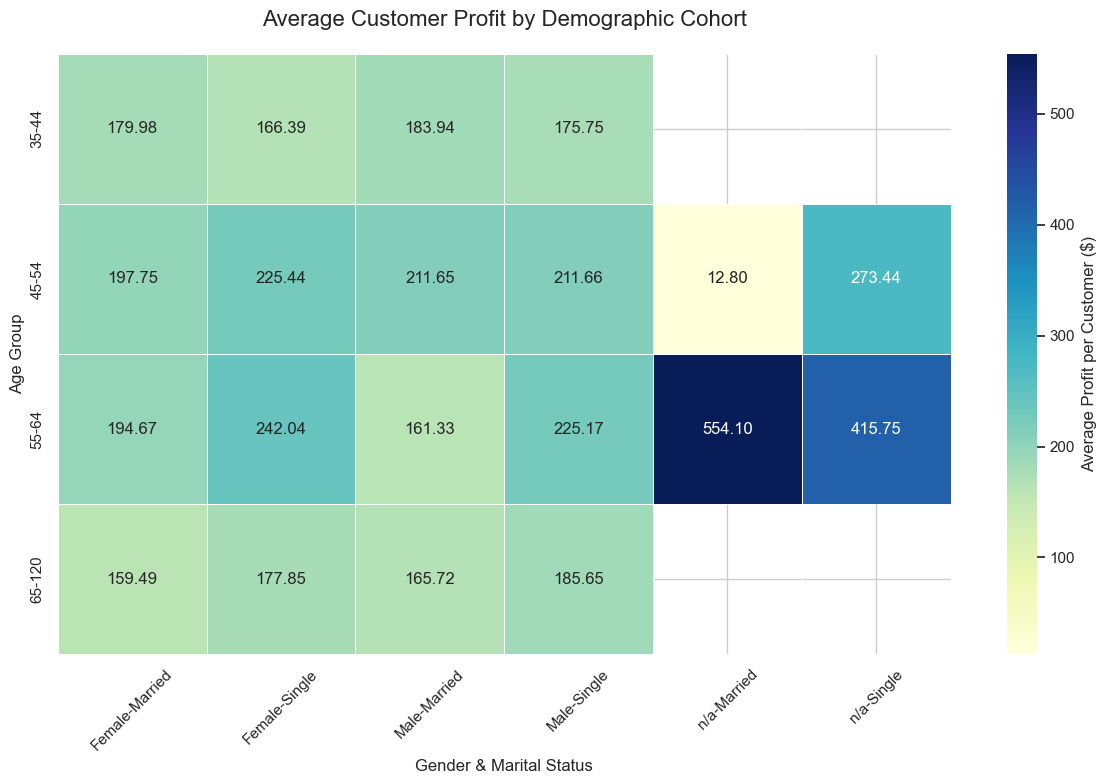

gender              Female                    Male                 n/a  \
marital_status     Married      Single     Married      Single Married   
age_group                                                                
35-44           179.980172  166.387321  183.942975  175.753463     NaN   
45-54           197.750416  225.435987  211.645830  211.663509    12.8   
55-64           194.665705  242.041888  161.329812  225.168621   554.1   
65-120          159.492825  177.852756  165.723077  185.649090     NaN   

gender                      
marital_status      Single  
age_group                   
35-44                  NaN  
45-54           273.444444  
55-64           415.750000  
65-120                 NaN

In [24]:
bins = [17,24,34,44,54,64,120]
labels = ['18-24', '25-34','35-44','45-54','55-64','65-120']
df['age_group'] = pd.cut(df['age'],bins=bins,labels=labels)
cohort_profits = df.groupby(['age_group','gender','marital_status'],observed=True)['total_profit'].mean().reset_index()

top_cohorts = cohort_profits.sort_values(by= 'total_profit', ascending=False)

pivot_cohorts = cohort_profits.pivot_table(
    index='age_group', 
    columns=['gender', 'marital_status'], 
    values='total_profit'
)

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

ax = sns.heatmap(
    pivot_cohorts, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Average Profit per Customer ($)'}
)
plt.title('Average Customer Profit by Demographic Cohort', fontsize=16, pad=20)
plt.xlabel('Gender & Marital Status', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
pivot_cohorts

### Do frequent buyers equal profitable buyers? Is there a correlation between the number of orders a customer places (order_number frequency) and their overall profit margin? Do loyal customers buy high-margin or low-margin goods?

Correlation between order frequency and profit margin: -0.092


C:\Users\Omkar\AppData\Local\Temp\ipykernel_24648\1074191935.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = lm, x = 'loyalty_tier', y = 'margin',palette= 'viridis',  )


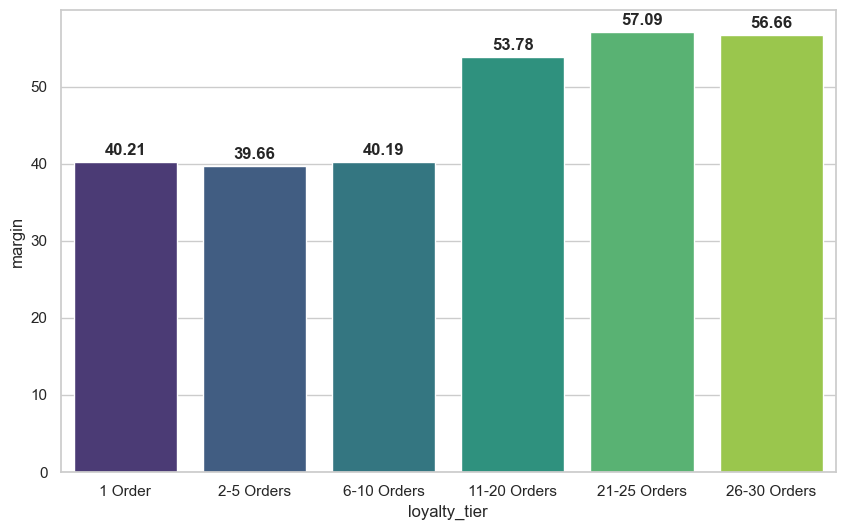

,loyalty_tier,customer_count,revenue,profit,margin
0,1 Order,11619,6747035,2712984,40.210018
1,2-5 Orders,6821,22473976,8913214,39.660156
2,6-10 Orders,9,100711,40478,40.192233
3,11-20 Orders,21,16879,9077,53.776883
4,21-25 Orders,1,1002,572,57.085828
5,26-30 Orders,13,16647,9432,56.658857


In [25]:
customer_stats = df.groupby('customer_key').agg(
    avg_profit_margin=('profit_margin%', 'mean'),
    total_orders = ('order_number','nunique'),
    total_revenue = ('sales_amount','sum'),
    total_profit = ('total_profit','sum')
).reset_index()


correlation = customer_stats['total_orders'].corr(customer_stats['avg_profit_margin'])

bins = [0,1,5,10,20,25,30]
labels = ['1 Order', '2-5 Orders', '6-10 Orders', '11-20 Orders', '21-25 Orders', '26-30 Orders']

customer_stats['loyalty_tier'] = pd.cut(customer_stats['total_orders'], bins=bins, labels=labels)
loyalty_metric = customer_stats.groupby('loyalty_tier').agg(
    customer_count = ('customer_key','count'),
    revenue = ('total_revenue', 'sum'),
    profit = ('total_profit', 'sum')
).reset_index()

loyalty_metric['margin'] = (loyalty_metric['profit'] / loyalty_metric['revenue'])  * 100

print(f"Correlation between order frequency and profit margin: {correlation:.3f}")
lm = loyalty_metric[['loyalty_tier', 'customer_count', 'margin']]

plt.figure(figsize=(10,6))
ax = sns.barplot(data = lm, x = 'loyalty_tier', y = 'margin',palette= 'viridis',  )

for i in ax.containers:
    ax.bar_label(i,fmt = '%.2f', padding=3, fontweight  = 'bold')

plt.show()
loyalty_metric

### Are there seasonal profitability dips? Using order_date, what does the month-over-month trend look like for Revenue vs. Profit Margin? Are our highest revenue months actually our least profitable due to heavy discounting?

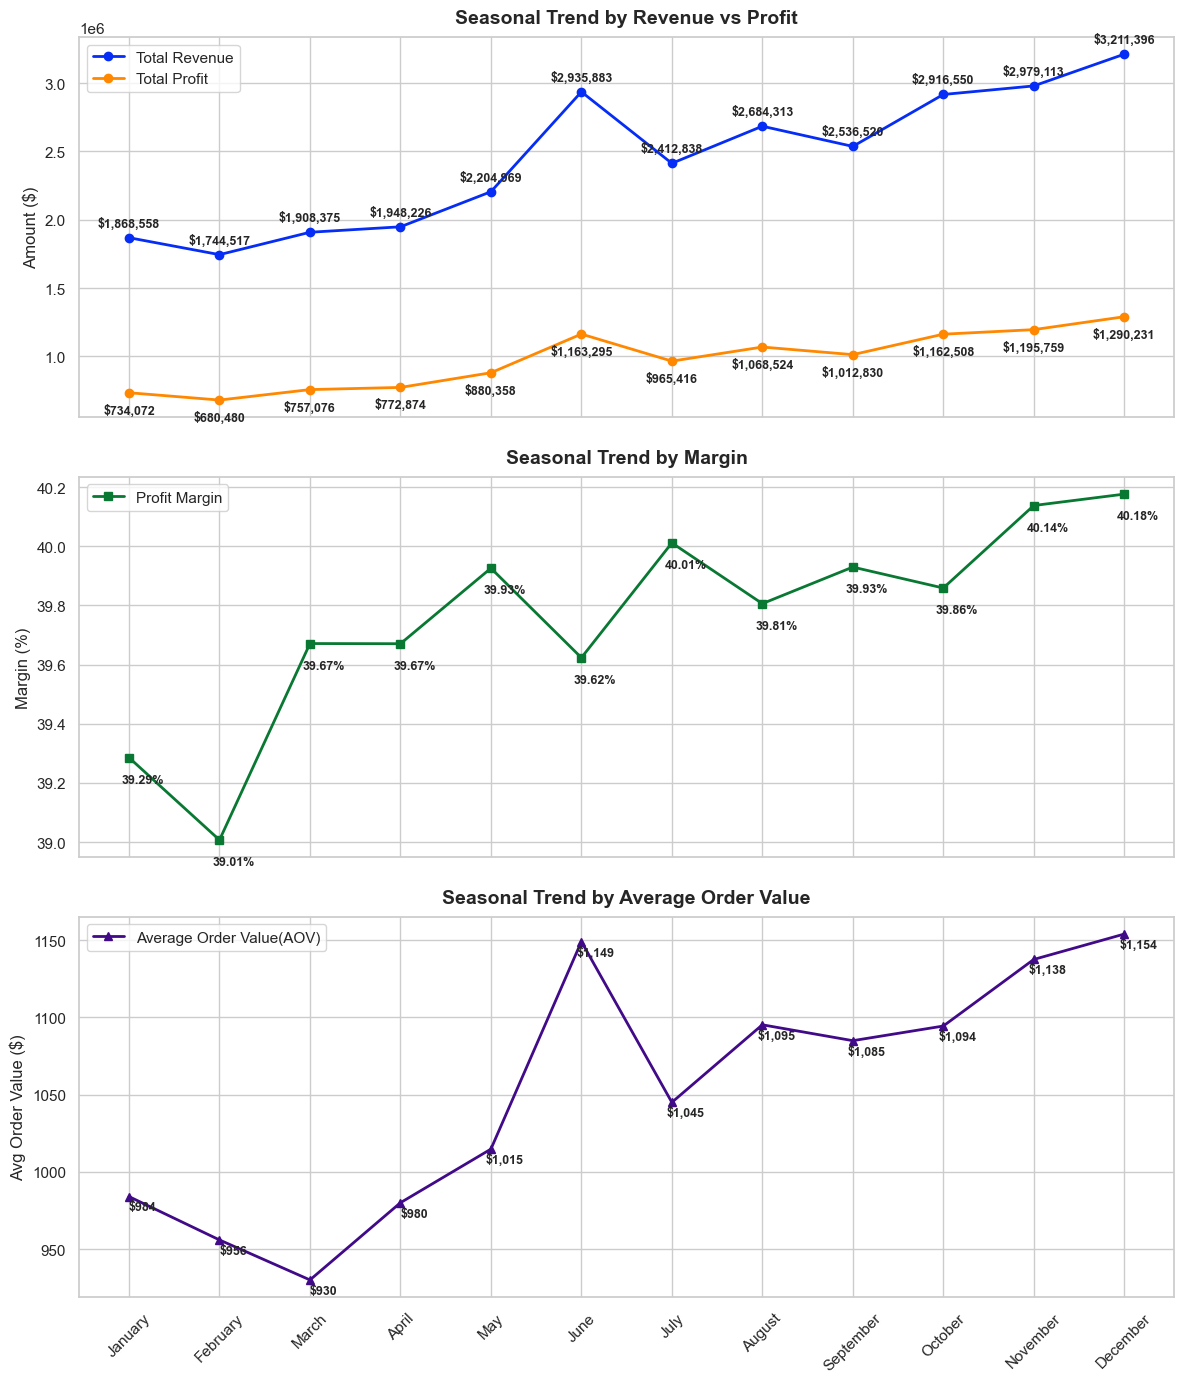

,month_num,month_name,total_revenue,total_profit,total_orders,margin,avg_order_value
0,1.0,January,1868558,734072,1899,39.285481,983.969458
1,2.0,February,1744517,680480,1825,39.006785,955.899726
2,3.0,March,1908375,757076,2052,39.671239,930.007310
3,4.0,April,1948226,772874,1988,39.670654,979.992958
4,5.0,May,2204969,880358,2173,39.926094,1014.711919
5,6.0,June,2935883,1163295,2555,39.623343,1149.073581
6,7.0,July,2412838,965416,2309,40.011638,1044.970983
7,8.0,August,2684313,1068524,2451,39.806237,1095.190942
8,9.0,September,2536520,1012830,2338,39.929904,1084.910180
9,10.0,October,2916550,1162508,2665,39.859012,1094.390244


In [26]:
seasonal_metric = df.groupby(['month_num','month_name']).agg(
    total_revenue = ('sales_amount', 'sum'),
    total_profit = ('total_profit', 'sum'),
    total_orders = ('order_number','nunique')
).reset_index()

seasonal_metric['margin'] = (seasonal_metric['total_profit'] / seasonal_metric['total_revenue']) * 100


seasonal_metric['avg_order_value'] = seasonal_metric['total_revenue'] / seasonal_metric['total_orders']


seasonal_metric = seasonal_metric.sort_values('month_num')

sns.set_theme(style='whitegrid')
fig,axes = plt.subplots(3,1,figsize = (12,14), sharex=True)

axes[0].plot(seasonal_metric['month_name'],seasonal_metric['total_revenue'], marker = 'o', linewidth = 2, label = 'Total Revenue',color = '#052DF5')
axes[0].plot(seasonal_metric['month_name'],seasonal_metric['total_profit'], marker = 'o', linewidth = 2, label = 'Total Profit', color = '#FF8800')
axes[0].set_title('Seasonal Trend by Revenue vs Profit', fontsize = 14, pad = 10, fontweight = 'bold')
axes[0].set_ylabel('Amount ($)', fontsize = 12)
axes[0].legend()

for i, row in seasonal_metric.iterrows():
    
    axes[0].annotate(f"${row['total_revenue']:,.0f}", 
                     (row['month_name'], row['total_revenue']),
                     textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9, fontweight = 'bold')
    
    axes[0].annotate(f"${row['total_profit']:,.0f}", 
                     (row['month_name'], row['total_profit']),
                     textcoords="offset points", xytext=(0, -15), ha='center', fontsize=9, fontweight = 'bold')

axes[1].plot(seasonal_metric['month_name'],seasonal_metric['margin'], marker = 's', linewidth = 2, label = 'Profit Margin', color = "#097832")
axes[1].set_title('Seasonal Trend by Margin', fontsize = 14, pad = 10, fontweight = 'bold')
axes[1].set_ylabel('Margin (%)', fontsize = 12)
axes[1].legend()

for i, row in seasonal_metric.iterrows():
    axes[1].annotate(f"{row['margin']:.2f}%",
                     (row['month_name'],row['margin']),
                     textcoords="offset points",xytext=(10, -18), ha='center',fontsize=9, fontweight = 'bold')

axes[2].plot(seasonal_metric['month_name'],seasonal_metric['avg_order_value'], marker = '^', linewidth = 2, label = 'Average Order Value(AOV)', color = "#410A88")
axes[2].set_title('Seasonal Trend by Average Order Value', fontsize = 14, pad = 10, fontweight = 'bold')
axes[2].set_ylabel('Avg Order Value ($)', fontsize = 12)
axes[2].legend()

for i,row in seasonal_metric.iterrows():
    axes[2].annotate(f"${row['avg_order_value']:,.0f}",
                     (row['month_name'],row['avg_order_value']),
                     textcoords = 'offset points', xytext = (10,-10), ha='center', fontsize=9, fontweight = 'bold')

plt.xticks(rotation = 45)

plt.tight_layout()

plt.show()
seasonal_metric

### Does shipping lag correlate with specific product lines? What is the average time between order_date and shipping_date for our most profitable vs. least profitable product categories?

In [27]:
ship_lag_metric = df.groupby(['product_line','category']).agg(
    total_profit = ('total_profit', 'sum'),
    shipping_lag = ('shipping_lag_days','mean')
    
)


ship_lag_metric


total_profit  shipping_lag
product_line category                               
Mountain     Accessories        142703           7.0
             Bikes             4354332           7.0
             Clothing            44836           7.0
Road         Accessories         63806           7.0
             Bikes             5300363           7.0
             Clothing             3408           7.0
Standard     Accessories        211707           7.0
             Clothing            88438           7.0
Touring      Accessories         21294           7.0
             Bikes             1454870           7.0

## Conclusion

- The top 10% of most profitable customers generate 41.21% of the company's overall profit.

- While high-revenue/low-profit customers make up only 0.31% of the total customer base, they account for a staggering 57.00% of the top 100 revenue-generating customers. This means the majority of "biggest spenders" are actually dragging down overall margin efficiency.

- Specific bike models namely the Mountain-200 and Road-150 series—are prime examples of revenue illusions. They drive massive top-line revenue (often over $1M individually) but suffer from bottom-tier effective margins ranging from 39.3% to 43.7%.

- According to the strict criteria applied (top 10% margin vs. bottom 20% volume), the analysis yielded no results, meaning there are currently no low-volume products with exceptionally high margins to easily scale up.  

 - There is a strong negative correlation (-0.55) between total product cost and effective margin. This reveals that as product costs increase, profit margins shrink, meaning increased base costs are not being adequately passed on to the consumer through pricing.

 - Products requiring maintenance severely cannibalize profitability. Items without maintenance boast an effective margin of 48.05%, while those requiring maintenance drop to 39.66%.

 - Canada is the most highly efficient region, ranking #1 in profit margin despite ranking near the bottom (#6) in total revenue.
  
- Australia presents a major geographical revenue illusion, driving the 2nd highest total sales but yielding the absolute worst profit margin per order

- The United States is the optimal target market, successfully balancing the #1 spot in total revenue with a highly efficient #2 ranking in profit margin

- While overall country-level average profit margins show a minor variance (ranging from 50.71% in Australia to 55.62% in Canada), the provided data does not break down profit margins for the same product categories across different countries to confirm specific regional pricing inefficiencies.

- The United States and Australia dominate most profitable customer base by generating over 62% of global profits, and these two countries will heavily populate any visual map of top 20% most profitable customers.

- While individual linear correlation is weak, cohort analysis clearly demonstrates that highly frequent buyers (11+ orders) are significantly more profitable because they consistently purchase higher-margin goods

- There is no correlation between shipping lag and product lines or profitability, as the average shipping lag is a constant 7 days across all product categories, from the most profitable to the least profitable.